In [8]:
"""
Ячейка 1: Загрузка трёх моделей-кандидатов для классификации
"""
from transformers import AutoTokenizer, AutoModel, AutoConfig
import torch
import time
import os

print("✅ Начало загрузки")

# Список моделей для тестирования
MODELS = {
    "rubert-tiny2": "cointegrated/rubert-tiny2",
    "rubert-base":  "DeepPavlov/rubert-base-cased",
    "xlm-roberta":  "xlm-roberta-base",
    "sbert_large_nlu_ru" : "ai-forever/sbert_large_nlu_ru",
}

# Загрузка и базовая информация
model_info = {}

for name, model_id in MODELS.items():
    print(f"\n{'='*60}")
    print(f"📥 Загрузка: {name} ({model_id})")
    print(f"{'='*60}")
    
    # Загрузка конфига (без скачивания весов)
    config = AutoConfig.from_pretrained(model_id)
    
    # Загрузка токенизатора
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    
    # Загрузка модели
    start = time.time()
    model = AutoModel.from_pretrained(model_id)
    load_time = time.time() - start
    
    # Подсчёт параметров
    num_params = sum(p.numel() for p in model.parameters())
    
    # Размер на диске (примерный)
    model_size_mb = sum(
        p.numel() * p.element_size() for p in model.parameters()
    ) / (1024 * 1024)
    
    info = {
        "hidden_size": config.hidden_size,
        "num_layers": config.num_hidden_layers,
        "num_params": num_params,
        "model_size_mb": model_size_mb,
        "vocab_size": config.vocab_size,
        "max_position": getattr(config, 'max_position_embeddings', 'N/A'),
        "load_time_sec": load_time,
    }
    model_info[name] = info
    
    print(f"  Hidden size:     {info['hidden_size']}")
    print(f"  Layers:          {info['num_layers']}")
    print(f"  Parameters:      {info['num_params']:,}")
    print(f"  Size (MB):       {info['model_size_mb']:.1f}")
    print(f"  Vocab size:      {info['vocab_size']:,}")
    print(f"  Max tokens:      {info['max_position']}")
    print(f"  Load time:       {info['load_time_sec']:.2f}s")

print("\n✅ Все модели загружены")

✅ Начало загрузки

📥 Загрузка: rubert-tiny2 (cointegrated/rubert-tiny2)


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Hidden size:     312
  Layers:          3
  Parameters:      29,193,768
  Size (MB):       111.4
  Vocab size:      83,828
  Max tokens:      2048
  Load time:       0.23s

📥 Загрузка: rubert-base (DeepPavlov/rubert-base-cased)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Hidden size:     768
  Layers:          12
  Parameters:      278,043,648
  Size (MB):       1060.7
  Vocab size:      250,002
  Max tokens:      514
  Load time:       0.36s

📥 Загрузка: sbert_large_nlu_ru (ai-forever/sbert_large_nlu_ru)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  Hidden size:     1024
  Layers:          24
  Parameters:      426,908,672
  Size (MB):       1628.5
  Vocab size:      120,138
  Max tokens:      512
  Load time:       0.45s

✅ Все модели загружены


In [9]:
"""
Ячейка 2: Замер скорости инференса на CPU
"""
import torch
import time

test_texts = [
    "Где мой заказ номер 123456?",
    "Хочу вернуть товар, он мне не подошёл по размеру",
    "Не могу оплатить заказ, карта не проходит, помогите пожалуйста",
    "Когда будет доставка в Новосибирск? Жду уже неделю",
    "Промокод СКИДКА2026 не работает при оформлении заказа",
]

results = {}

for name, model_id in MODELS.items():
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id)
    model.eval()
    
    times = []
    
    for text in test_texts:
        # Прогрев (первый запуск всегда медленнее)
        with torch.no_grad():
            encoded = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
            _ = model(**encoded)
        
        # Замер (среднее по 10 прогонам)
        text_times = []
        for _ in range(10):
            start = time.perf_counter()
            with torch.no_grad():
                encoded = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
                output = model(**encoded)
            elapsed = (time.perf_counter() - start) * 1000  # ms
            text_times.append(elapsed)
        
        avg_time = sum(text_times) / len(text_times)
        times.append(avg_time)
    
    results[name] = {
        "avg_ms": sum(times) / len(times),
        "min_ms": min(times),
        "max_ms": max(times),
    }
    
    print(f"\n📊 {name}:")
    print(f"   Среднее: {results[name]['avg_ms']:.1f} ms")
    print(f"   Мин:     {results[name]['min_ms']:.1f} ms")
    print(f"   Макс:    {results[name]['max_ms']:.1f} ms")

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 rubert-tiny2:
   Среднее: 3.6 ms
   Мин:     3.3 ms
   Макс:    3.7 ms


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 xlm-roberta:
   Среднее: 36.9 ms
   Мин:     31.6 ms
   Макс:    42.2 ms


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]


📊 sbert_large_nlu_ru:
   Среднее: 115.4 ms
   Мин:     103.8 ms
   Макс:    127.5 ms


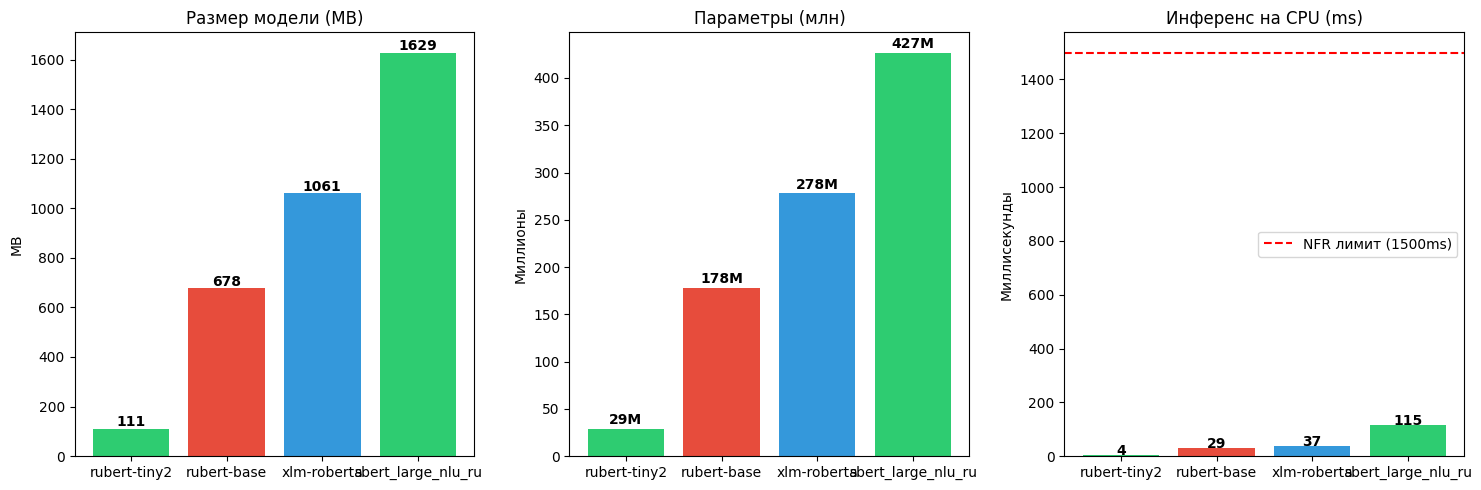

✅ График сохранён в results/model_comparison.png


In [10]:
"""
Ячейка 3: Графики сравнения моделей
"""
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

names = list(model_info.keys())

# График 1: Размер модели
sizes = [model_info[n]['model_size_mb'] for n in names]
colors = ['#2ecc71', '#e74c3c', '#3498db']
axes[0].bar(names, sizes, color=colors)
axes[0].set_title('Размер модели (MB)')
axes[0].set_ylabel('MB')
for i, v in enumerate(sizes):
    axes[0].text(i, v + 10, f'{v:.0f}', ha='center', fontweight='bold')

# График 2: Количество параметров
params = [model_info[n]['num_params'] / 1e6 for n in names]
axes[1].bar(names, params, color=colors)
axes[1].set_title('Параметры (млн)')
axes[1].set_ylabel('Миллионы')
for i, v in enumerate(params):
    axes[1].text(i, v + 5, f'{v:.0f}M', ha='center', fontweight='bold')

# График 3: Скорость инференса
speeds = [results[n]['avg_ms'] for n in names]
axes[2].bar(names, speeds, color=colors)
axes[2].set_title('Инференс на CPU (ms)')
axes[2].set_ylabel('Миллисекунды')
axes[2].axhline(y=1500, color='red', linestyle='--', label='NFR лимит (1500ms)')
axes[2].legend()
for i, v in enumerate(speeds):
    axes[2].text(i, v + 2, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ График сохранён в results/model_comparison.png")

In [11]:
"""
Ячейка 4: Как каждая модель токенизирует русский текст
"""
test_phrase = "Здравствуйте, хочу вернуть бракованный товар и получить деньги обратно"

for name, model_id in MODELS.items():
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    
    tokens = tokenizer.tokenize(test_phrase)
    ids = tokenizer.encode(test_phrase)
    
    print(f"\n{'='*60}")
    print(f"🔤 {name}")
    print(f"{'='*60}")
    print(f"  Исходный текст:  {test_phrase}")
    print(f"  Кол-во токенов:  {len(tokens)}")
    print(f"  Токены:          {tokens}")
    print(f"  Token IDs:       {ids[:10]}... (первые 10)")


🔤 rubert-tiny2
  Исходный текст:  Здравствуйте, хочу вернуть бракованный товар и получить деньги обратно
  Кол-во токенов:  11
  Токены:          ['Здравствуйте', ',', 'хочу', 'вернуть', 'браков', '##анный', 'товар', 'и', 'получить', 'деньги', 'обратно']
  Token IDs:       [2, 54471, 16, 30473, 31392, 62500, 36263, 34512, 320, 18348]... (первые 10)

🔤 rubert-base
  Исходный текст:  Здравствуйте, хочу вернуть бракованный товар и получить деньги обратно
  Кол-во токенов:  12
  Токены:          ['Здравствуй', '##те', ',', 'хочу', 'вернуть', 'браков', '##анный', 'товар', 'и', 'получить', 'деньги', 'обратно']
  Token IDs:       [101, 109531, 5306, 128, 34087, 13694, 44084, 9589, 33412, 851]... (первые 10)

🔤 xlm-roberta
  Исходный текст:  Здравствуйте, хочу вернуть бракованный товар и получить деньги обратно
  Кол-во токенов:  13
  Токены:          ['▁Здравствуйте', ',', '▁хочу', '▁', 'вернуть', '▁брак', 'ова', 'нный', '▁товар', '▁и', '▁получить', '▁деньги', '▁обратно']
  Token IDs:       

In [12]:
"""
Ячейка 5: Semantic similarity между фразами — без fine-tuning
"""
import torch
from torch.nn.functional import cosine_similarity

phrases = [
    # Группа 1: заказ
    "Где мой заказ?",
    "Какой статус моей посылки?",
    "Когда придёт мой заказ?",
    # Группа 2: возврат
    "Хочу вернуть товар",
    "Как оформить возврат?",
    "Верните мне деньги",
    # Группа 3: доставка
    "Сколько стоит доставка?",
    "Какие способы доставки есть?",
    # Группа 4: нерелевантное
    "Какая погода завтра?",
    "Расскажи анекдот",
]

for name, model_id in MODELS.items():
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id)
    model.eval()
    
    # Получение CLS-эмбеддингов
    embeddings = []
    for phrase in phrases:
        with torch.no_grad():
            encoded = tokenizer(phrase, return_tensors="pt", truncation=True, padding=True)
            output = model(**encoded)
            cls = output.last_hidden_state[:, 0, :]  # CLS token
            embeddings.append(cls.squeeze())
    
    embeddings = torch.stack(embeddings)
    
    # Матрица similarity
    print(f"\n{'='*60}")
    print(f"📊 Similarity Matrix: {name}")
    print(f"{'='*60}")
    print(f"{'':30s}", end="")
    for i in range(len(phrases)):
        print(f" [{i:2d}]", end="")
    print()
    
    for i in range(len(phrases)):
        print(f"[{i:2d}] {phrases[i][:28]:28s}", end="")
        for j in range(len(phrases)):
            sim = cosine_similarity(
                embeddings[i].unsqueeze(0),
                embeddings[j].unsqueeze(0)
            ).item()
            print(f" {sim:.2f}", end="")
        print()

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 Similarity Matrix: rubert-tiny2
                               [ 0] [ 1] [ 2] [ 3] [ 4] [ 5] [ 6] [ 7] [ 8] [ 9]
[ 0] Где мой заказ?               1.00 0.84 0.85 0.59 0.69 0.60 0.73 0.69 0.61 0.57
[ 1] Какой статус моей посылки?   0.84 1.00 0.76 0.59 0.70 0.55 0.76 0.72 0.63 0.56
[ 2] Когда придёт мой заказ?      0.85 0.76 1.00 0.61 0.68 0.61 0.72 0.64 0.61 0.56
[ 3] Хочу вернуть товар           0.59 0.59 0.61 1.00 0.67 0.74 0.58 0.52 0.39 0.55
[ 4] Как оформить возврат?        0.69 0.70 0.68 0.67 1.00 0.61 0.80 0.79 0.61 0.59
[ 5] Верните мне деньги           0.60 0.55 0.61 0.74 0.61 1.00 0.56 0.48 0.44 0.65
[ 6] Сколько стоит доставка?      0.73 0.76 0.72 0.58 0.80 0.56 1.00 0.86 0.63 0.57
[ 7] Какие способы доставки есть? 0.69 0.72 0.64 0.52 0.79 0.48 0.86 1.00 0.61 0.53
[ 8] Какая погода завтра?         0.61 0.63 0.61 0.39 0.61 0.44 0.63 0.61 1.00 0.50
[ 9] Расскажи анекдот             0.57 0.56 0.56 0.55 0.59 0.65 0.57 0.53 0.50 1.00


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 Similarity Matrix: xlm-roberta
                               [ 0] [ 1] [ 2] [ 3] [ 4] [ 5] [ 6] [ 7] [ 8] [ 9]
[ 0] Где мой заказ?               1.00 1.00 1.00 0.99 1.00 0.99 0.98 1.00 1.00 0.99
[ 1] Какой статус моей посылки?   1.00 1.00 1.00 1.00 0.99 1.00 0.97 0.99 1.00 1.00
[ 2] Когда придёт мой заказ?      1.00 1.00 1.00 1.00 1.00 1.00 0.98 1.00 1.00 1.00
[ 3] Хочу вернуть товар           0.99 1.00 1.00 1.00 0.98 1.00 0.95 0.98 1.00 1.00
[ 4] Как оформить возврат?        1.00 0.99 1.00 0.98 1.00 0.98 0.99 1.00 0.99 0.98
[ 5] Верните мне деньги           0.99 1.00 1.00 1.00 0.98 1.00 0.95 0.99 1.00 1.00
[ 6] Сколько стоит доставка?      0.98 0.97 0.98 0.95 0.99 0.95 1.00 0.99 0.97 0.96
[ 7] Какие способы доставки есть? 1.00 0.99 1.00 0.98 1.00 0.99 0.99 1.00 1.00 0.99
[ 8] Какая погода завтра?         1.00 1.00 1.00 1.00 0.99 1.00 0.97 1.00 1.00 1.00
[ 9] Расскажи анекдот             0.99 1.00 1.00 1.00 0.98 1.00 0.96 0.99 1.00 1.00


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]


📊 Similarity Matrix: sbert_large_nlu_ru
                               [ 0] [ 1] [ 2] [ 3] [ 4] [ 5] [ 6] [ 7] [ 8] [ 9]
[ 0] Где мой заказ?               1.00 0.71 0.85 0.62 0.51 0.71 0.68 0.40 0.40 0.27
[ 1] Какой статус моей посылки?   0.71 1.00 0.68 0.60 0.63 0.61 0.72 0.57 0.39 0.23
[ 2] Когда придёт мой заказ?      0.85 0.68 1.00 0.61 0.52 0.64 0.71 0.43 0.51 0.31
[ 3] Хочу вернуть товар           0.62 0.60 0.61 1.00 0.62 0.74 0.57 0.40 0.26 0.30
[ 4] Как оформить возврат?        0.51 0.63 0.52 0.62 1.00 0.57 0.62 0.55 0.30 0.27
[ 5] Верните мне деньги           0.71 0.61 0.64 0.74 0.57 1.00 0.56 0.27 0.27 0.29
[ 6] Сколько стоит доставка?      0.68 0.72 0.71 0.57 0.62 0.56 1.00 0.69 0.43 0.22
[ 7] Какие способы доставки есть? 0.40 0.57 0.43 0.40 0.55 0.27 0.69 1.00 0.36 0.21
[ 8] Какая погода завтра?         0.40 0.39 0.51 0.26 0.30 0.27 0.43 0.36 1.00 0.32
[ 9] Расскажи анекдот             0.27 0.23 0.31 0.30 0.27 0.29 0.22 0.21 0.32 1.00
